In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../outputs/cleaned_retail.csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Year,Month,MonthName,Quarter,Week,Day,DayName,Hour,Weekend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,December,4,49,1,Tuesday,7,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,4,49,1,Tuesday,7,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,4,49,1,Tuesday,7,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,December,4,49,1,Tuesday,7,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,December,4,49,1,Tuesday,7,False


In [3]:
inventory = df.groupby("StockCode").agg({

    "Description":"first",

    "Quantity":"sum",

    "TotalSales":"sum",

    "InvoiceNo":"nunique"

}).reset_index()

In [4]:
inventory.columns = [

    "StockCode",

    "Description",

    "UnitsSold",

    "Revenue",

    "Orders"

]

inventory.head()

,StockCode,Description,UnitsSold,Revenue,Orders
0,10002,INFLATABLE POLITICAL GLOBE,8479,6638.27,297
1,10080,GROOVY CACTUS INFLATABLE,303,124.61,26
2,10109,BENDY COLOUR PENCILS,4,1.68,1
3,10120,DOGGY RUBBER,648,136.08,62
4,10123C,HEARTS WRAPPING TAPE,628,226.76,46


In [5]:
days = (

    pd.to_datetime(df["InvoiceDate"]).max()

    -

    pd.to_datetime(df["InvoiceDate"]).min()

).days

inventory["DailyDemand"] = (

    inventory["UnitsSold"]

    /

    days

)

In [6]:
np.random.seed(42)

inventory["CurrentStock"] = np.random.randint(

    20,

    300,

    size=len(inventory)

)

In [7]:
inventory["SafetyStock"] = (

    inventory["DailyDemand"]

    *7

)

In [8]:
inventory["ReorderPoint"] = (

    inventory["DailyDemand"]

    *14

)

In [9]:
inventory["StockoutRisk"] = np.where(

    inventory["CurrentStock"]

    <

    inventory["ReorderPoint"],

    "High",

    "Low"

)

In [10]:
inventory["OverstockRisk"] = np.where(

    inventory["CurrentStock"]

    >

    inventory["DailyDemand"]*60,

    "High",

    "Low"

)

In [11]:
def recommendation(row):

    if (

        row["StockoutRisk"]=="High"

        and

        row["OverstockRisk"]=="Low"

    ):

        return "Reorder"

    elif (

        row["OverstockRisk"]=="High"

        and

        row["StockoutRisk"]=="Low"

    ):

        return "Markdown"

    elif (

        row["StockoutRisk"]=="High"

        and

        row["OverstockRisk"]=="High"

    ):

        return "Review"

    else:

        return "Healthy"

inventory["Recommendation"] = inventory.apply(

    recommendation,

    axis=1

)

In [12]:
inventory["Recommendation"].value_counts()

Recommendation
Markdown    3234
Healthy      969
Reorder      428
Name: count, dtype: int64

In [13]:
inventory.head(20)

,StockCode,Description,UnitsSold,Revenue,Orders,DailyDemand,CurrentStock,SafetyStock,ReorderPoint,StockoutRisk,OverstockRisk,Recommendation
0,10002,INFLATABLE POLITICAL GLOBE,8479,6638.27,297,11.489160,122,80.424119,160.848238,High,Low,Reorder
1,10080,GROOVY CACTUS INFLATABLE,303,124.61,26,0.410569,290,2.873984,5.747967,Low,High,Markdown
2,10109,BENDY COLOUR PENCILS,4,1.68,1,0.005420,126,0.037940,0.075881,Low,High,Markdown
3,10120,DOGGY RUBBER,648,136.08,62,0.878049,91,6.146341,12.292683,Low,High,Markdown
4,10123C,HEARTS WRAPPING TAPE,628,226.76,46,0.850949,208,5.956640,11.913279,Low,High,Markdown
5,10123G,ARMY CAMO WRAPPING TAPE,2246,157.18,12,3.043360,40,21.303523,42.607046,High,Low,Reorder
6,10124A,SPOTS ON RED BOOKCOVER TAPE,58,24.36,18,0.078591,122,0.550136,1.100271,Low,High,Markdown
7,10124G,ARMY CAMO BOOKCOVER TAPE,32,13.44,9,0.043360,141,0.303523,0.607046,Low,High,Markdown
8,10125,MINI FUNKY DESIGN TAPES,1970,1562.70,120,2.669377,234,18.685637,37.371274,Low,High,Markdown
9,10133,COLOURING PENCILS BROWN TUBE,3307,1910.79,203,4.481030,107,31.367209,62.734417,Low,Low,Healthy


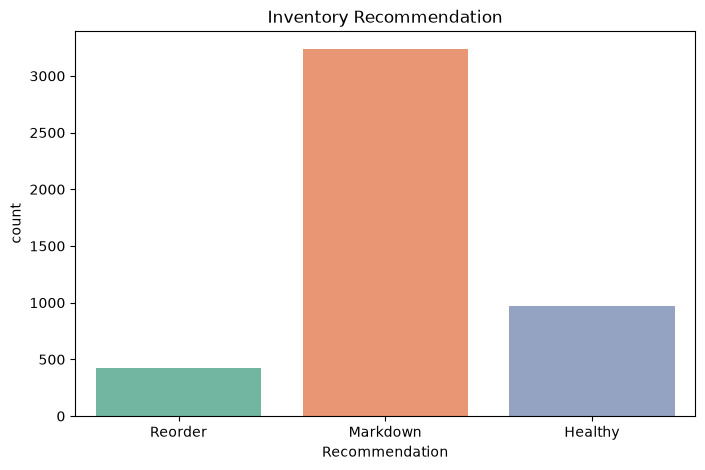

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(

    data=inventory,

    x="Recommendation",

    palette="Set2"

)

plt.title("Inventory Recommendation")

plt.show()

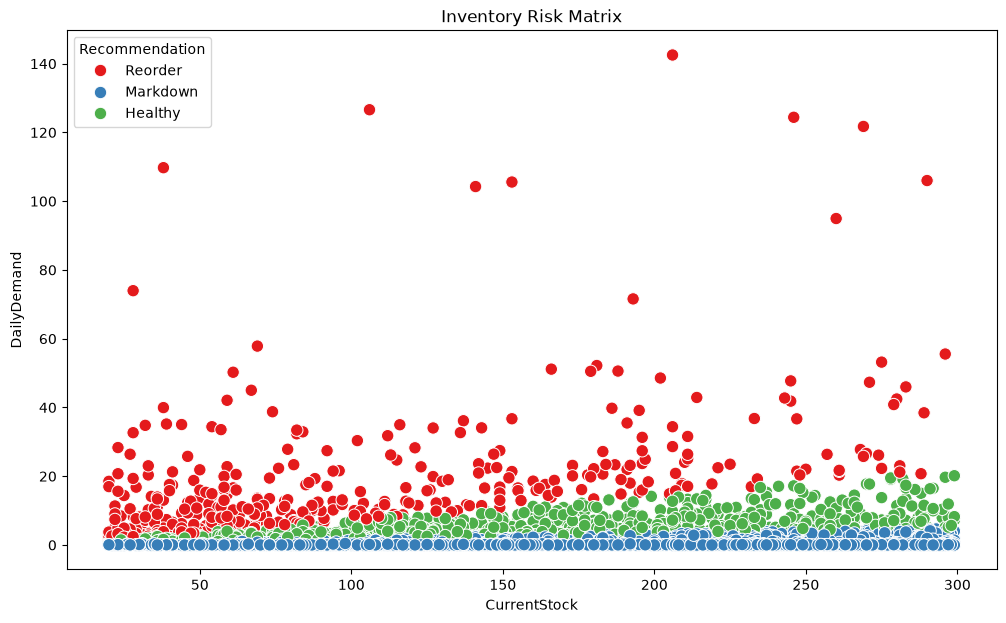

In [15]:
plt.figure(figsize=(12,7))

sns.scatterplot(

    data=inventory,

    x="CurrentStock",

    y="DailyDemand",

    hue="Recommendation",

    palette="Set1",

    s=80

)

plt.title("Inventory Risk Matrix")

plt.show()

In [16]:
inventory[

    inventory["Recommendation"]=="Reorder"

].sort_values(

    "Revenue",

    ascending=False

).head(20)

,StockCode,Description,UnitsSold,Revenue,Orders,DailyDemand,CurrentStock,SafetyStock,ReorderPoint,StockoutRisk,OverstockRisk,Recommendation
1609,22423,REGENCY CAKESTAND 3 TIER,24124,277656.25,3317,32.688347,136,228.818428,457.636856,High,Low,Reorder
4080,85123A,WHITE HANGING HEART T-LIGHT HOLDER,91814,247203.36,4895,124.409214,246,870.864499,1741.728997,High,Low,Reorder
2726,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,109.749322,38,768.245257,1536.490515,High,Low,Reorder
4058,85099B,JUMBO BAG RED WHITE SPOTTY,93436,167920.64,3260,126.607046,106,886.249322,1772.498645,High,Low,Reorder
3819,84879,ASSORTED COLOUR BIRD ORNAMENT,78234,124351.86,2652,106.008130,290,742.056911,1484.113821,High,Low,Reorder
3059,47566,PARTY BUNTING,23460,103283.38,2077,31.788618,112,222.520325,445.040650,High,Low,Reorder
2324,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,195,105.577236,153,739.040650,1478.081301,High,Low,Reorder
1298,22086,PAPER CHAIN KIT 50'S CHRISTMAS,28380,76598.18,1691,38.455285,289,269.186992,538.373984,High,Low,Reorder
3321,79321,CHILLI LIGHTS,14843,69084.30,922,20.112466,173,140.787263,281.574526,High,Low,Reorder
1578,22386,JUMBO BAG PINK WITH WHITE SPOTS,37338,67769.76,1767,50.593496,188,354.154472,708.308943,High,Low,Reorder


In [17]:
inventory[

    inventory["Recommendation"]=="Markdown"

].sort_values(

    "Revenue",

    ascending=False

).head(20)

,StockCode,Description,UnitsSold,Revenue,Orders,DailyDemand,CurrentStock,SafetyStock,ReorderPoint,StockoutRisk,OverstockRisk,Recommendation
3411,84078A,SET/4 WHITE RETRO STORAGE CUBES,1007,36259.65,234,1.364499,277,9.551491,19.102981,Low,High,Markdown
1925,22752,SET 7 BABUSHKA NESTING BOXES,3273,25620.99,577,4.434959,296,31.044715,62.089431,Low,High,Markdown
2957,37503,TEA TIME CAKE STAND IN GIFT BOX,2384,23784.80,465,3.230352,214,22.612466,45.224932,Low,High,Markdown
1379,22171,3 HOOK PHOTO SHELF ANTIQUE WHITE,2999,21458.42,544,4.063686,286,28.445799,56.891599,Low,High,Markdown
264,20749,ASSORTED COLOUR MINI CASES,2972,21169.64,726,4.027100,299,28.189702,56.379404,Low,High,Markdown
1781,22605,WOODEN CROQUET GARDEN SET,1710,20813.81,548,2.317073,199,16.219512,32.439024,Low,High,Markdown
2915,37449,CERAMIC CAKE STAND + HANGING CAKES,2277,20204.58,410,3.085366,190,21.597561,43.195122,Low,High,Markdown
1682,22501,PICNIC BASKET WICKER LARGE,2055,18794.25,497,2.784553,261,19.491870,38.983740,Low,High,Markdown
707,21340,CLASSIC METAL BIRDCAGE PLANT HOLDER,1702,17888.71,383,2.306233,221,16.143631,32.287263,Low,High,Markdown
2017,22847,"BREAD BIN, DINER STYLE, IVORY",1094,17018.54,445,1.482385,232,10.376694,20.753388,Low,High,Markdown


In [18]:
inventory.to_csv(

    "../outputs/inventory_risk.csv",

    index=False

)

print("Inventory Risk Completed Successfully")

Inventory Risk Completed Successfully
